In [2]:
import pandas as pd

In [3]:
df_movies = pd.read_csv('movie.csv')
df_tag = pd.read_csv('tag.csv')
df_rating = pd.read_csv('rating.csv')
df_link = pd.read_csv('link.csv')
df_genome_scores = pd.read_csv('genome_scores.csv')
df_genome_tags = pd.read_csv('genome_tags.csv')



Preprocessing

Feature Engineering: Genre Encoding

In [4]:
df_movies['genres'] = df_movies['genres'].apply(lambda x: str(x).split('|'))
display(df_movies)
all_genres = set(genre 
for list in df_movies['genres'] for genre in list)
display(all_genres)
for genre in all_genres:
     df_movies[genre]= df_movies['genres'].apply(lambda x: 1 if genre in x else 0)
df_movies = df_movies.drop('genres', axis=1)
display(df_movies)

,movieId,title,genres
0,1,Toy Story (1995),"[Adventure, Animation, Children, Comedy, Fantasy]"
1,2,Jumanji (1995),"[Adventure, Children, Fantasy]"
2,3,Grumpier Old Men (1995),"[Comedy, Romance]"
3,4,Waiting to Exhale (1995),"[Comedy, Drama, Romance]"
4,5,Father of the Bride Part II (1995),[Comedy]
...,...,...,...
27273,131254,Kein Bund für's Leben (2007),[Comedy]
27274,131256,"Feuer, Eis & Dosenbier (2002)",[Comedy]
27275,131258,The Pirates (2014),[Adventure]
27276,131260,Rentun Ruusu (2001),[(no genres listed)]


{'(no genres listed)',
 'Action',
 'Adventure',
 'Animation',
 'Children',
 'Comedy',
 'Crime',
 'Documentary',
 'Drama',
 'Fantasy',
 'Film-Noir',
 'Horror',
 'IMAX',
 'Musical',
 'Mystery',
 'Romance',
 'Sci-Fi',
 'Thriller',
 'War',
 'Western'}

,movieId,title,Adventure,Fantasy,Documentary,Horror,Sci-Fi,IMAX,(no genres listed),War,...,Musical,Drama,Comedy,Crime,Action,Western,Romance,Animation,Children,Film-Noir
0,1,Toy Story (1995),1,1,0,0,0,0,0,0,...,0,0,1,0,0,0,0,1,1,0
1,2,Jumanji (1995),1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,3,Grumpier Old Men (1995),0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,1,0,0,0
3,4,Waiting to Exhale (1995),0,0,0,0,0,0,0,0,...,0,1,1,0,0,0,1,0,0,0
4,5,Father of the Bride Part II (1995),0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27273,131254,Kein Bund für's Leben (2007),0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
27274,131256,"Feuer, Eis & Dosenbier (2002)",0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
27275,131258,The Pirates (2014),1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
27276,131260,Rentun Ruusu (2001),0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


Creating user item matrix

In [21]:
from scipy.sparse import csr_matrix
movieId_mapping = {movieId : i for i,movieId in enumerate(df_rating['movieId'].unique())}
df_rating['mapped_MovieId'] = df_rating['movieId'].map(movieId_mapping)
user_item_sparse = csr_matrix((df_rating['rating'], 
                               (df_rating['userId'], df_rating['mapped_MovieId'])))

print(user_item_sparse)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 20000263 stored elements and shape (138494, 26744)>
  Coords	Values
  (1, 0)	3.5
  (1, 1)	3.5
  (1, 2)	3.5
  (1, 3)	3.5
  (1, 4)	3.5
  (1, 5)	3.5
  (1, 6)	4.0
  (1, 7)	4.0
  (1, 8)	4.0
  (1, 9)	4.0
  (1, 10)	4.0
  (1, 11)	4.0
  (1, 12)	4.0
  (1, 13)	3.5
  (1, 14)	3.5
  (1, 15)	4.0
  (1, 16)	3.5
  (1, 17)	3.5
  (1, 18)	3.0
  (1, 19)	3.5
  (1, 20)	3.5
  (1, 21)	3.5
  (1, 22)	4.0
  (1, 23)	4.0
  (1, 24)	3.5
  :	:
  (138493, 5844)	3.0
  (138493, 5970)	5.0
  (138493, 6121)	4.5
  (138493, 6156)	4.5
  (138493, 6565)	3.5
  (138493, 6591)	5.0
  (138493, 7124)	5.0
  (138493, 7315)	3.5
  (138493, 7421)	4.0
  (138493, 7557)	4.0
  (138493, 7717)	4.0
  (138493, 7722)	4.5
  (138493, 7733)	4.5
  (138493, 7953)	5.0
  (138493, 8056)	5.0
  (138493, 8233)	5.0
  (138493, 8890)	5.0
  (138493, 9527)	4.0
  (138493, 9547)	4.5
  (138493, 9648)	4.5
  (138493, 9787)	4.5
  (138493, 10743)	4.5
  (138493, 11011)	4.5
  (138493, 11504)	5.0
  (138493, 11614)

Merging Movies with Tags and Genome Scores

These merged datasets are used to enhance movie features with tag-based relevance scoring.

In [6]:
from sklearn.preprocessing import MinMaxScaler
movies_with_tags = pd.merge(df_movies, df_tag, how='inner',left_on='movieId', right_on='movieId' )
scores_with_tags = pd.merge(df_genome_scores, df_genome_tags, how='inner', left_on='tagId', right_on='tagId')
display(movies_with_tags)
display(scores_with_tags)

,movieId,title,Adventure,Fantasy,Documentary,Horror,Sci-Fi,IMAX,(no genres listed),War,...,Crime,Action,Western,Romance,Animation,Children,Film-Noir,userId,tag,timestamp
0,1,Toy Story (1995),1,1,0,0,0,0,0,0,...,0,0,0,0,1,1,0,1644,Watched,2014-12-04 23:44:40
1,1,Toy Story (1995),1,1,0,0,0,0,0,0,...,0,0,0,0,1,1,0,1741,computer animation,2007-07-08 13:59:15
2,1,Toy Story (1995),1,1,0,0,0,0,0,0,...,0,0,0,0,1,1,0,1741,Disney animated feature,2007-07-08 22:21:47
3,1,Toy Story (1995),1,1,0,0,0,0,0,0,...,0,0,0,0,1,1,0,1741,Pixar animation,2007-07-08 22:46:10
4,1,Toy Story (1995),1,1,0,0,0,0,0,0,...,0,0,0,0,1,1,0,1741,TÃ©a Leoni does not star in this movie,2009-06-15 19:19:33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
465559,131258,The Pirates (2014),1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,28906,bandits,2015-03-30 19:57:01
465560,131258,The Pirates (2014),1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,28906,Korea,2015-03-30 19:58:32
465561,131258,The Pirates (2014),1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,28906,mutiny,2015-03-30 19:59:02
465562,131258,The Pirates (2014),1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,28906,pirates,2015-03-30 19:56:59


,movieId,tagId,relevance,tag
0,1,1,0.02500,007
1,1,2,0.02500,007 (series)
2,1,3,0.05775,18th century
3,1,4,0.09675,1920s
4,1,5,0.14675,1930s
...,...,...,...,...
11709763,131170,1124,0.58775,writing
11709764,131170,1125,0.01075,wuxia
11709765,131170,1126,0.01575,wwii
11709766,131170,1127,0.11450,zombie


Calculating Tag Usage Counts

This step prepares the data for weighting tag relevance scores based on their frequency of use.

In [7]:
tag_counts = movies_with_tags.groupby(['movieId','tag']).size().reset_index(name='count')
display(tag_counts)
scores_with_tags = pd.merge(scores_with_tags, tag_counts, how='left', on =['movieId', 'tag'])
scores_with_tags['count'] = scores_with_tags['count'].fillna(0) 
display(scores_with_tags)




,movieId,tag,count
0,1,2009 reissue in Stereoscopic 3-D,1
1,1,3D,3
2,1,55 movies every kid should see--Entertainment ...,1
3,1,Animation,1
4,1,BD-Video,1
...,...,...,...
200360,131258,Korea,1
200361,131258,bandits,1
200362,131258,mutiny,1
200363,131258,pirates,1


,movieId,tagId,relevance,tag,count
0,1,1,0.02500,007,0.0
1,1,2,0.02500,007 (series),0.0
2,1,3,0.05775,18th century,0.0
3,1,4,0.09675,1920s,0.0
4,1,5,0.14675,1930s,0.0
...,...,...,...,...,...
11709763,131170,1124,0.58775,writing,0.0
11709764,131170,1125,0.01075,wuxia,0.0
11709765,131170,1126,0.01575,wwii,0.0
11709766,131170,1127,0.11450,zombie,0.0


,movieId,tagId,relevance,tag,count
28,1,29,0.89200,adventure,10.0
62,1,63,0.93325,animated,10.0
63,1,64,0.98575,animation,48.0
169,1,170,0.45025,buddy movie,4.0
192,1,193,0.81925,cgi,3.0
...,...,...,...,...,...
11690394,129659,931,0.91475,small town,1.0
11690422,129659,959,0.99625,sports,1.0
11700850,130490,107,0.99125,based on a book,1.0
11707196,131013,813,0.95825,prison,1.0


Scaling Tag Relevance Scores

This step is crucial for avoiding numerical underflow when combining relevance scores with other weighted features.

In [9]:
scaling_factor = 1e3
scores_with_tags['scaled_relevance'] = scores_with_tags['relevance'] * scaling_factor
 
display(scores_with_tags)

,movieId,tagId,relevance,tag,count,scaled_relevance
0,1,1,0.02500,007,0.0,25.00
1,1,2,0.02500,007 (series),0.0,25.00
2,1,3,0.05775,18th century,0.0,57.75
3,1,4,0.09675,1920s,0.0,96.75
4,1,5,0.14675,1930s,0.0,146.75
...,...,...,...,...,...,...
11709763,131170,1124,0.58775,writing,0.0,587.75
11709764,131170,1125,0.01075,wuxia,0.0,10.75
11709765,131170,1126,0.01575,wwii,0.0,15.75
11709766,131170,1127,0.11450,zombie,0.0,114.50


Adjusting Tag Counts

This step is essential for maintaining meaningful contributions from tags with low or no explicit counts.

In [10]:
scores_with_tags['count'] = scores_with_tags['count']+1
display(scores_with_tags)

,movieId,tagId,relevance,tag,count,scaled_relevance
0,1,1,0.02500,007,1.0,25.00
1,1,2,0.02500,007 (series),1.0,25.00
2,1,3,0.05775,18th century,1.0,57.75
3,1,4,0.09675,1920s,1.0,96.75
4,1,5,0.14675,1930s,1.0,146.75
...,...,...,...,...,...,...
11709763,131170,1124,0.58775,writing,1.0,587.75
11709764,131170,1125,0.01075,wuxia,1.0,10.75
11709765,131170,1126,0.01575,wwii,1.0,15.75
11709766,131170,1127,0.11450,zombie,1.0,114.50


Weighting and Pivoting Tag Relevance

This step transforms the dataset into a movie-tag feature matrix, where each movie is represented by its relevance scores across all tags.

In [11]:
scores_with_tags['scaled_relevance'] = scores_with_tags['scaled_relevance'] * scores_with_tags['count']
relevance_features = scores_with_tags.pivot_table(index='movieId', columns= 'tag',values='scaled_relevance')
display(relevance_features)

tag,007,007 (series),18th century,1920s,1930s,1950s,1960s,1970s,1980s,19th century,...,world politics,world war i,world war ii,writer's life,writers,writing,wuxia,wwii,zombie,zombies
movieId,,,,,,,,,,,,,,,,,,,,,
1,25.00,25.00,57.75,96.75,146.75,217.00,67.00,262.75,262.00,32.00,...,39.50,18.00,45.75,32.75,125.00,41.50,19.25,36.25,77.75,23.00
2,39.75,43.75,37.75,48.00,110.25,72.50,47.75,109.75,99.25,20.50,...,41.75,19.25,17.25,24.25,125.50,22.50,15.50,14.75,90.25,18.75
3,43.50,54.75,28.00,77.00,54.00,68.50,56.00,185.00,49.25,26.75,...,41.50,26.75,27.75,34.25,155.50,36.75,17.00,19.50,97.00,18.50
4,37.25,39.50,36.75,31.00,68.25,40.50,23.25,87.00,51.25,30.25,...,57.50,33.75,22.75,39.75,185.25,59.25,15.00,15.25,64.50,13.00
5,42.00,52.75,59.25,36.75,75.25,125.25,28.50,85.00,29.50,28.75,...,42.50,28.25,21.50,26.00,142.75,20.75,16.50,16.75,107.50,18.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130578,154.00,40.25,19.75,18.50,28.50,22.75,10.00,36.75,10.25,15.75,...,28.75,11.25,12.50,20.50,210.00,23.75,42.25,5.25,75.75,13.25
130840,24.00,30.25,24.25,93.75,56.00,60.25,21.00,129.00,112.75,36.50,...,21.25,42.50,10.25,203.50,476.75,107.75,62.00,7.75,270.00,133.75
131013,42.00,31.75,17.00,56.00,57.50,26.75,16.00,42.00,28.00,37.25,...,66.75,13.00,12.75,22.75,200.00,107.50,25.00,9.50,75.50,16.25


Merging Movie Metadata with Tag Features

The resulting movie_features DataFrame represents each movie as a numerical feature vector based on its genres and tag relevance scores.

In [12]:
movie_features = pd.merge(df_movies, relevance_features, how='inner', left_on= 'movieId', right_on= 'movieId')
movie_features = movie_features.drop('title', axis=1)

display(movie_features)

,movieId,Adventure,Fantasy,Documentary,Horror,Sci-Fi,IMAX,(no genres listed),War,Thriller,...,world politics,world war i,world war ii,writer's life,writers,writing,wuxia,wwii,zombie,zombies
0,1,1,1,0,0,0,0,0,0,0,...,39.50,18.00,45.75,32.75,125.00,41.50,19.25,36.25,77.75,23.00
1,2,1,1,0,0,0,0,0,0,0,...,41.75,19.25,17.25,24.25,125.50,22.50,15.50,14.75,90.25,18.75
2,3,0,0,0,0,0,0,0,0,0,...,41.50,26.75,27.75,34.25,155.50,36.75,17.00,19.50,97.00,18.50
3,4,0,0,0,0,0,0,0,0,0,...,57.50,33.75,22.75,39.75,185.25,59.25,15.00,15.25,64.50,13.00
4,5,0,0,0,0,0,0,0,0,0,...,42.50,28.25,21.50,26.00,142.75,20.75,16.50,16.75,107.50,18.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10376,130578,0,0,0,0,0,0,0,0,1,...,28.75,11.25,12.50,20.50,210.00,23.75,42.25,5.25,75.75,13.25
10377,130840,0,0,0,1,1,0,0,0,0,...,21.25,42.50,10.25,203.50,476.75,107.75,62.00,7.75,270.00,133.75
10378,131013,0,0,0,0,0,0,0,0,0,...,66.75,13.00,12.75,22.75,200.00,107.50,25.00,9.50,75.50,16.25
10379,131168,0,0,0,0,0,0,0,0,0,...,203.00,163.25,810.25,19.00,181.75,32.25,48.00,519.25,67.00,17.25


Calculating Cosine Similarity Between Movies

This similarity matrix is the core of the content-based recommendation system. It allows us to easily identify movies that are most similar to any given movie based on their features.

In [13]:
from sklearn.metrics.pairwise import cosine_similarity

cosine_movies = cosine_similarity(movie_features)
df_cosine_movies = pd.DataFrame(cosine_movies, index=movie_features.index,columns =  movie_features.index)
display(df_cosine_movies)

,0,1,2,3,4,5,6,7,8,9,...,10371,10372,10373,10374,10375,10376,10377,10378,10379,10380
0,1.000000,0.185549,0.196336,0.136865,0.201361,0.066278,0.069278,0.219893,0.112791,0.067660,...,0.015637,0.006904,0.004601,0.007103,0.018485,0.003124,0.005407,0.007512,0.006477,0.008785
1,0.185549,1.000000,0.256979,0.259675,0.256590,0.092814,0.128915,0.409994,0.265652,0.118850,...,0.015142,0.014267,0.013280,0.014500,0.014462,0.007417,0.011904,0.010079,0.011310,0.018154
2,0.196336,0.256979,1.000000,0.587759,0.731084,0.274091,0.342517,0.579235,0.503925,0.251770,...,0.029748,0.024349,0.025058,0.026943,0.025279,0.015803,0.028443,0.026874,0.029782,0.037851
3,0.136865,0.259675,0.587759,1.000000,0.552023,0.254241,0.495120,0.642858,0.495970,0.218720,...,0.029925,0.023837,0.026925,0.026863,0.026034,0.016251,0.031698,0.024133,0.031811,0.038539
4,0.201361,0.256590,0.731084,0.552023,1.000000,0.188280,0.432452,0.518486,0.438481,0.198769,...,0.027807,0.021367,0.020892,0.023344,0.023684,0.013018,0.024211,0.021949,0.025335,0.032889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10376,0.003124,0.007417,0.015803,0.016251,0.013018,0.010381,0.008660,0.018337,0.023538,0.011392,...,0.999264,0.999595,0.999340,0.999502,0.999287,1.000000,0.999147,0.999286,0.998891,0.998471
10377,0.005407,0.011904,0.028443,0.031698,0.024211,0.016546,0.018353,0.028258,0.025451,0.011258,...,0.999028,0.999295,0.998955,0.999101,0.999002,0.999147,1.000000,0.998960,0.999115,0.998793
10378,0.007512,0.010079,0.026874,0.024133,0.021949,0.010996,0.011510,0.024562,0.023937,0.010358,...,0.999160,0.999438,0.999099,0.999237,0.999187,0.999286,0.998960,1.000000,0.998653,0.998483
10379,0.006477,0.011310,0.029782,0.031811,0.025335,0.022105,0.016430,0.030947,0.027282,0.013330,...,0.998767,0.998975,0.998632,0.998865,0.998732,0.998891,0.999115,0.998653,1.000000,0.998421


Visualizing Cosine Similarity with a Heatmap

This visualization helps spot clusters of highly similar movies and understand patterns in movie relationships.

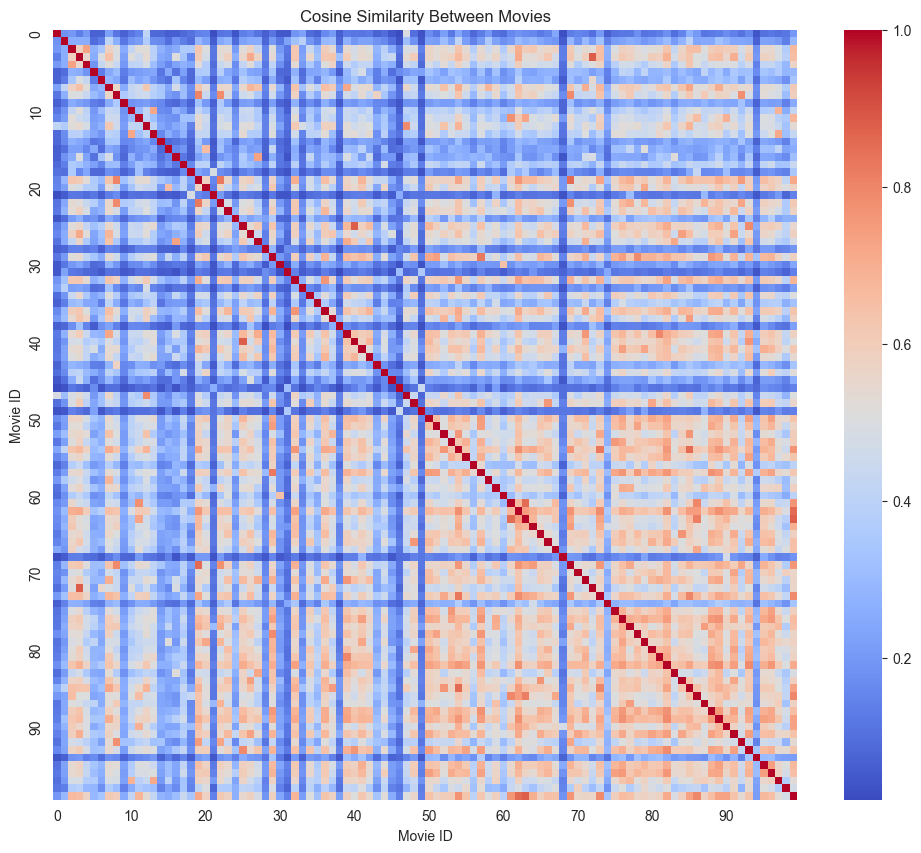

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

subset = df_cosine_movies.iloc[:100, :100]

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(subset, annot=False, fmt=".2f", cmap="coolwarm", 
            xticklabels=10, yticklabels=10)

# Add titles and labels
plt.title("Cosine Similarity Between Movies")
plt.xlabel("Movie ID")
plt.ylabel("Movie ID")
plt.show()

Mapping Movies to Similar Movies

This step generates a content-based recommendation dataset, where each movie is linked to a set of highly similar movies based on their features.

In [15]:
treshold = 0.7 
similarity_map = {}
for movieId in df_cosine_movies.index:
    similarities = df_cosine_movies.loc[movieId]
    sim_movies = similarities[similarities > treshold].index.to_list()
    sim_movies.remove(movieId)
    similarity_map[movieId] = sim_movies


Creating a DataFrame for Similar Movies

In [50]:
similar_movies_df = pd.DataFrame(columns=["movie_id", "similar_movies"])

for movie_id, similar_movies in similarity_map.items():
    new_row  = pd.DataFrame({
        "movie_id": [movie_id],
        "similar_movies": [similar_movies]
    })
    similar_movies_df = pd.concat([similar_movies_df, new_row], ignore_index=True)

display(similar_movies_df)

,movie_id,similar_movies
0,0,"[2064, 2769, 3809, 4331, 4602, 5445]"
1,1,[]
2,2,"[4, 117, 279, 390, 395, 407, 445, 462, 464, 51..."
3,3,"[26, 62, 72, 91, 113, 117, 155, 166, 169, 182,..."
4,4,"[2, 834]"
...,...,...
10376,10376,"[3054, 3275, 3298, 3438, 3583, 3586, 3623, 363..."
10377,10377,"[3054, 3275, 3298, 3438, 3583, 3586, 3623, 363..."
10378,10378,"[3054, 3275, 3298, 3438, 3583, 3586, 3623, 363..."
10379,10379,"[3054, 3275, 3298, 3438, 3583, 3586, 3623, 363..."


Clustering Movies Based on User Ratings

This step creates collaborative filtering-based clusters, grouping movies rated similarly by users into the same cluster.

In [24]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

reduced_df_movies = df_movies[df_movies['movieId'].isin(df_rating['movieId'].unique())].copy()
scaler = StandardScaler(with_mean=False)
normalized_matrix = scaler.fit_transform(user_item_sparse.T)
kmeans = KMeans(n_clusters=10, random_state=42)
movie_clusters = kmeans.fit_predict(normalized_matrix)
reduced_df_movies['rating_cluster'] = movie_clusters

,movieId,title,Adventure,Fantasy,Documentary,Horror,Sci-Fi,IMAX,(no genres listed),War,...,Musical,Drama,Comedy,Crime,Action,Western,Romance,Animation,Children,Film-Noir
0,1,Toy Story (1995),1,1,0,0,0,0,0,0,...,0,0,1,0,0,0,0,1,1,0
1,2,Jumanji (1995),1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
2,3,Grumpier Old Men (1995),0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,1,0,0,0
3,4,Waiting to Exhale (1995),0,0,0,0,0,0,0,0,...,0,1,1,0,0,0,1,0,0,0
4,5,Father of the Bride Part II (1995),0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0


In [32]:
for num in reduced_df_movies['rating_cluster'].unique():
    length = len(reduced_df_movies[reduced_df_movies['rating_cluster'] == num])
    print(f'for cluster {num} we have {length} movies')

for cluster 7 we have 78 movies
for cluster 1 we have 26266 movies
for cluster 9 we have 32 movies
for cluster 3 we have 4 movies
for cluster 0 we have 322 movies
for cluster 8 we have 5 movies
for cluster 2 we have 3 movies
for cluster 4 we have 6 movies
for cluster 6 we have 5 movies
for cluster 5 we have 23 movies


Mapping Clusters to Movies

This step organizes the collaborative filtering results into a convenient dictionary format, linking clusters to their associated movies.

In [53]:
cluster_map = {}
for _ , movie in reduced_df_movies.iterrows():
    cluster = movie['rating_cluster']
    movie_id = movie['movieId']
    
    if cluster not in cluster_map:
        cluster_map[cluster] = []
    
    cluster_map[cluster].append(movie_id) 

    


Creating a DataFrame for Clustered Movies

In [52]:
df_clustered_movies = pd.DataFrame(columns = ['cluster', 'movies'])
for cluster, list_of_movies in cluster_map.items():
    new_row = pd.DataFrame( {
        'cluster' : [cluster],
    'movies' : [list_of_movies]
    })
    df_clustered_movies = pd.concat([df_clustered_movies, new_row], ignore_index=True)
display(df_clustered_movies)

,cluster,movies
0,7,"[1, 7, 11, 14, 15, 182, 232, 233, 235, 238, 23..."
1,1,"[2, 22, 38, 42, 47, 53, 55, 56, 61, 63, 64, 65..."
2,9,"[3, 6, 19, 177, 178, 191, 230, 245, 246, 254, ..."
3,3,"[4, 5, 9, 651]"
4,0,"[8, 16, 20, 21, 23, 24, 25, 26, 27, 28, 29, 30..."
5,8,"[10, 31, 32, 188, 189]"
6,2,"[12, 13, 18]"
7,4,"[17, 184, 373, 376, 400, 660]"
8,6,"[98, 133, 144, 160, 335]"
9,5,"[180, 236, 237, 240, 369, 371, 377, 380, 396, ..."
